In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('Housing.csv')

In [4]:
display(df.head(10))

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [5]:
rows,columns =df.shape
print("rows:",rows)
print("columns:",columns)

rows: 545
columns: 13


In [6]:
print("Target Column:'price'")
print("Feature Columns:columns other than 'price'('area', 'bedrooms', 'bathrooms', etc.)")

Target Column:'price'
Feature Columns:columns other than 'price'('area', 'bedrooms', 'bathrooms', etc.)


In [7]:
#to count black or null values
print("Checking missing values in each column:")
print(df.isnull().sum())

Checking missing values in each column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [8]:
# to drop rows containing null values or blank values
df = df.dropna()
rows,column=df.shape

In [9]:
#to remove duplicate rows
df=df.drop_duplicates()
print(f"Dropped {rows - df.shape[0]} duplicate rows.")

Dropped 0 duplicate rows.


In [10]:
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
df_cleaned = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the cleaned dataset to verify
display(df_cleaned.head())

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Splitting our data into features(X) and target(Y)
X = df_cleaned.drop('price', axis=1)
y = df_cleaned['price']

# Split the data into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Training the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("***** Linear Regression Performance *****")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, lr_preds):.2f}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, lr_preds)):.2f}")
print(f"R² Score: {r2_score(y_test, lr_preds):.4f}\n")

# 2. Training the Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("***** Random Forest Performance *****")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, rf_preds):.2f}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, rf_preds)):.2f}")
print(f"R² Score: {r2_score(y_test, rf_preds):.4f}")

***** Linear Regression Performance *****
Mean Absolute Error: 970043.40
Root Mean Squared Error: 1324506.96
R² Score: 0.6529

***** Random Forest Performance *****
Mean Absolute Error: 1021546.04
Root Mean Squared Error: 1400565.97
R² Score: 0.6119


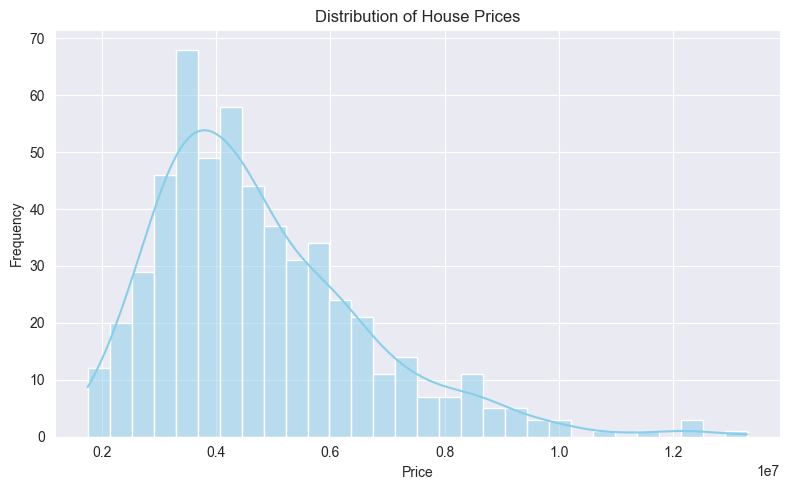

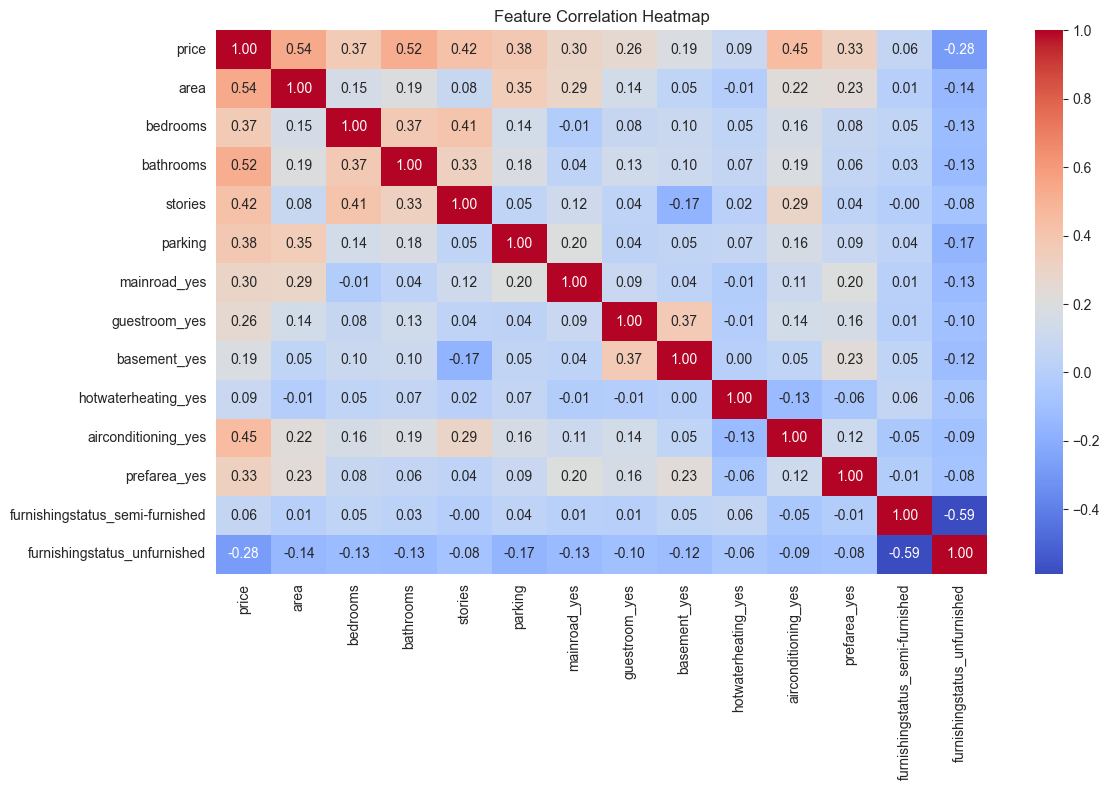

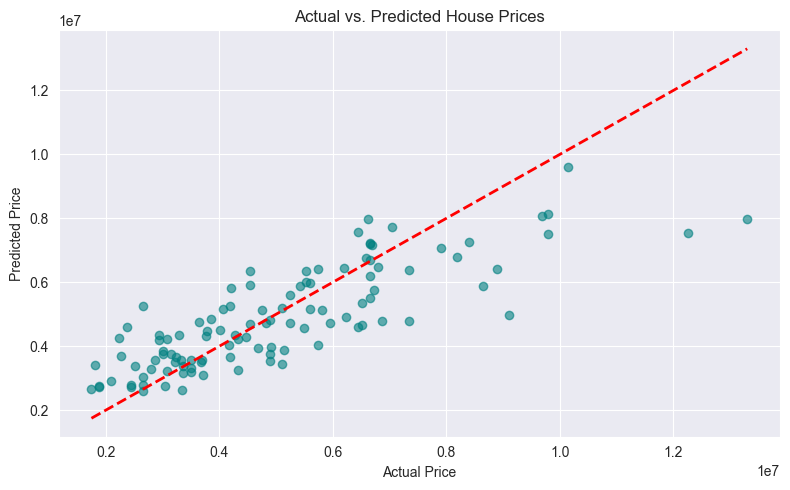

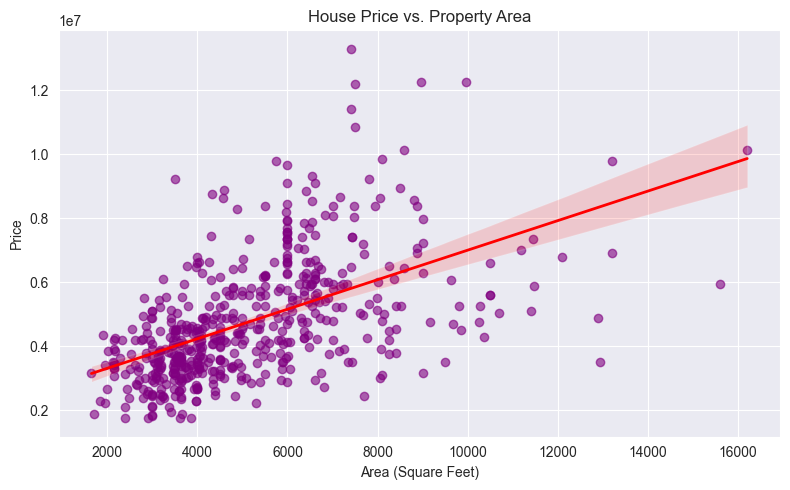

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Creating a charts directory if it doesn't exist to save our PNGs
os.makedirs('charts', exist_ok=True)

# Chart 1: Histogram showing the distribution of house prices
plt.figure(figsize=(8, 5))
sns.histplot(df_cleaned['price'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('charts/price_distribution.png')
plt.show()

# Chart 2: Correlation heatmap showing which features relate most strongly to price
plt.figure(figsize=(12, 8))
correlation_matrix = df_cleaned.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png')
plt.show()

# Chart 3: Actual vs. Predicted Price Scatter Plot (Using Linear Regression)
plt.figure(figsize=(8, 5))
plt.scatter(y_test, lr_preds, alpha=0.6, color='teal')
# Drawing the "Perfect Prediction" diagonal line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted House Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.tight_layout()
plt.savefig('charts/actual_vs_predicted.png')
plt.show()

# Chart 4: Area vs. Price Scatter Plot with Trend Line
plt.figure(figsize=(8, 5))

# sns.regplot automatically plots the scatter points AND draws the line of best fit
sns.regplot(x=df_cleaned['area'], y=df_cleaned['price'],
            scatter_kws={'alpha':0.6, 'color':'purple'}, # Styles the dots
            line_kws={'color':'red', 'lw':2})            # Styles the straight line

plt.title('House Price vs. Property Area')
plt.xlabel('Area (Square Feet)')
plt.ylabel('Price')
plt.tight_layout()

# Save the new chart
plt.savefig('charts/area_vs_price_trend.png')
plt.show()

### Insights & Summary
Based on the correlation heatmap, the features that influence house prices the most are the **total property area**, **number of bathrooms**, and whether the house has **air conditioning**.Our chosen model **Linear Regression** is reasonably accurate; it achieved an R² score of ~0.65, meaning it successfully explains 65% of the variations in house prices. What surprised me the most in the data was that the basic Linear Regression model slightly outperformed the generally more powerful Random Forest model, and that features like hot water heating had a surprisingly low correlation with the overall price. Based on these findings, my recommendation for a real estate business would be to prioritize acquiring properties with larger square footage and multiple bathrooms, or to add air conditioning to existing listings as a cost-effective way to significantly boost the property's market value.